In [1]:
import numpy as np
from src import util

from src.linear_model import LinearModel

In [2]:
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
class LocallyWeightedRegression(LinearModel):
    def __init__(self,tau=0.5):
        super().__init__()
        self.tau=tau
    def fit(self,x,y):
        self.x=x
        self.y=y
    def predict(self,x):
        def w(X,x_sample,tau):
            m,n=X.shape
            l,n=x_sample.shape
            diff=(np.reshape(X,(m,-1,n))-np.reshape(x_sample,(-1,l,n)))
            #diff=np.reshape(X,(m,-1,n))-np.reshape(x_test,(-1,l,n))
            w_vector=np.exp(-np.linalg.norm(diff,ord=2,axis=2)**2/(2*tau**2))
            W=np.apply_along_axis(np.diag,axis=0,arr=w_vector).T           
            return W
        W=w(self.x,x,self.tau)   
        self.theta=np.linalg.inv(self.x.T@W@self.x)@self.x.T@W@self.y
        return np.sum(x*self.theta,axis=1)
        
        
        

In [4]:
x_train, y_train = util.load_dataset('data/ds5_train.csv', add_intercept=True)
x_valid, y_valid = util.load_dataset('data/ds5_valid.csv', add_intercept=True)
x_test, y_test = util.load_dataset('data/ds5_test.csv', add_intercept=True)

In [5]:
lwr=LocallyWeightedRegression()
lwr.fit(x_train, y_train)
predictions_train=lwr.predict(x_train)

In [6]:
f"Mean squared error on train set: {np.mean(np.pow(predictions_train-y_train,2))}"

'Mean squared error on train set: 0.3253523595021209'

In [7]:
def plot(x,y,predictions,labels,title,colors):
    fig,ax=plt.subplots()
    sns.scatterplot(x=x,y=y,label=labels[0],marker='X',color=colors[0])
    sns.scatterplot(x=x,y=predictions,label=labels[1],color=colors[1])
    ax.set_title(title)
    plt.show()

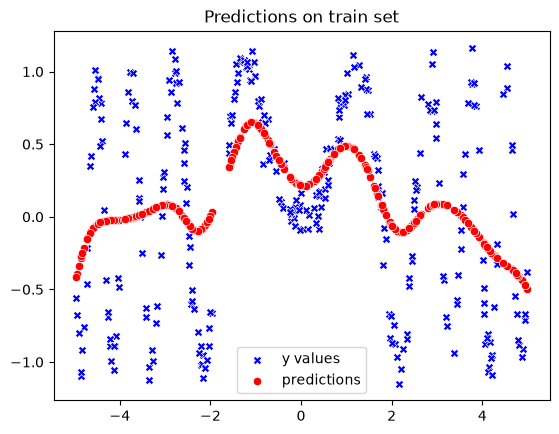

In [8]:
plot(x_train[:,1],y_train,predictions_train,('y values','predictions'),'Predictions on train set',('blue','red'))

In [9]:
predictions_valid=lwr.predict(x_valid)

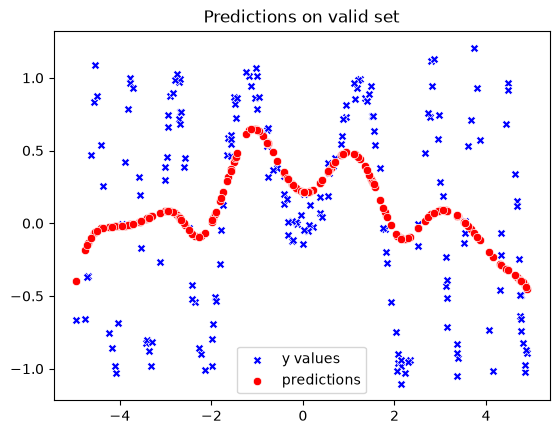

In [10]:
plot(x_valid[:,1],y_valid,predictions_valid,('y values','predictions'),'Predictions on valid set',('blue','red'))

In [11]:
f"Mean squared error on valid set: {np.mean(np.pow(predictions_valid-y_valid,2))}"

'Mean squared error on valid set: 0.33053126821375267'

In [12]:
def test_taus(taus):
    best_mse=np.inf
    best_tau=0
    for tau in taus:
        lwr=LocallyWeightedRegression(tau)
        lwr.fit(x_train,y_train)
        predictions=lwr.predict(x_valid)
        mse=np.mean(np.pow(predictions-y_valid,2))
        if mse<best_mse:
            best_mse=mse
            best_tau=tau
        print(f"tau={tau}, mse={mse}")
        plot(x_valid[:,1],y_valid,predictions,('y values','predictions'),f'Predictions on valid set for tau={tau}',('blue','red'))
    print("Best tau:",best_tau)

[0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]


[0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
tau=0.01, mse=0.22179058676378113


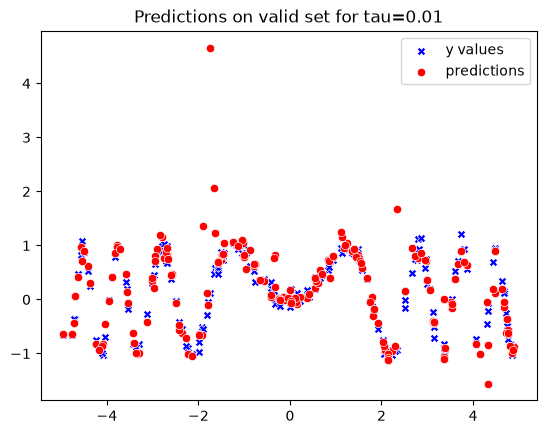

tau=0.05, mse=0.01240007615046591


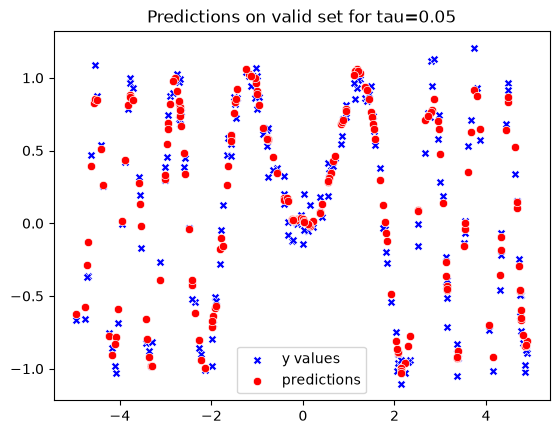

tau=0.1, mse=0.024224589379807267


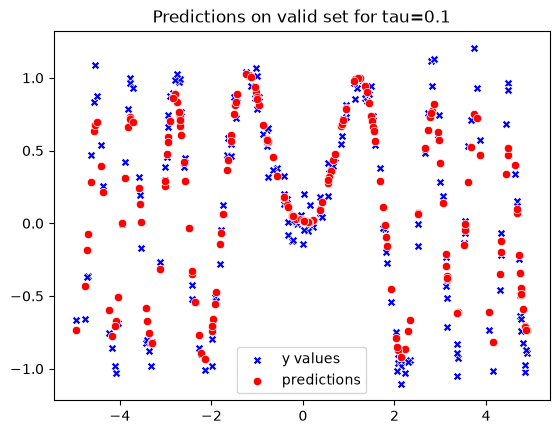

tau=0.5, mse=0.33053126821375267


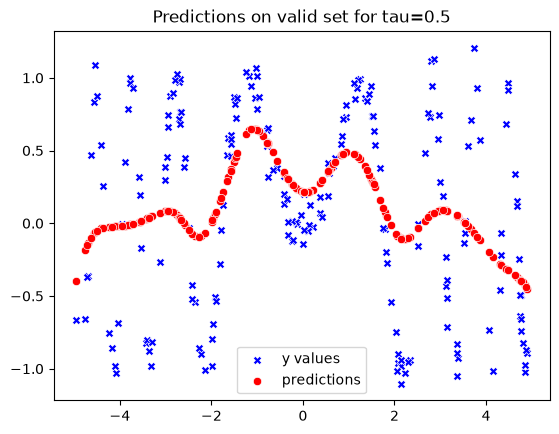

tau=1, mse=0.4000959480180862


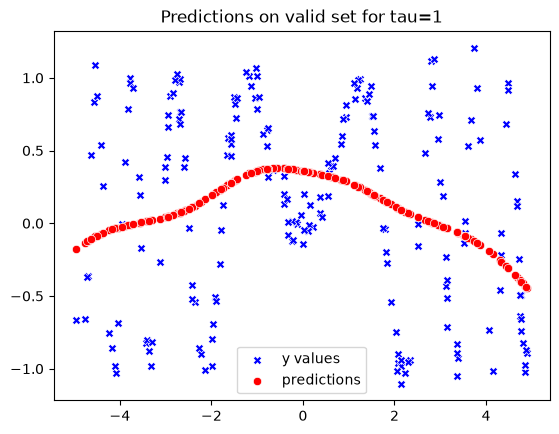

tau=5, mse=0.42389128123602376


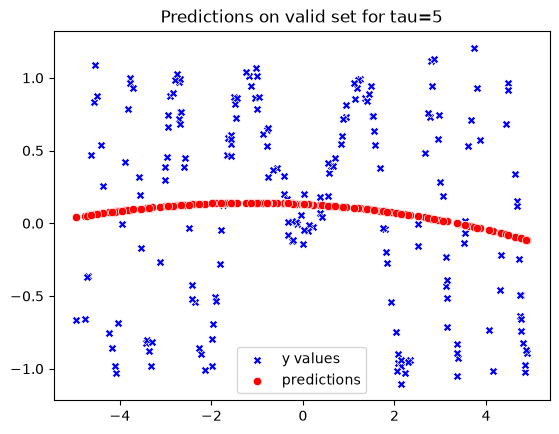

tau=10, mse=0.4337439227232362


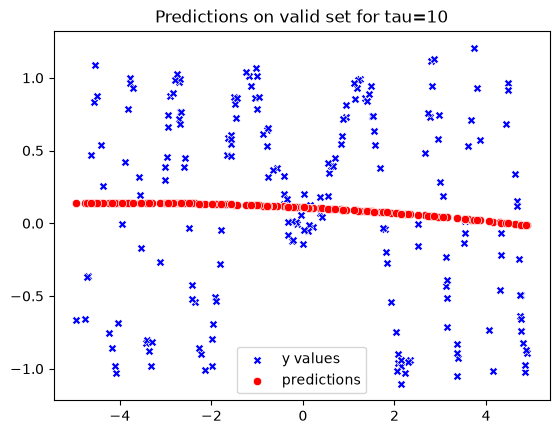

tau=50, mse=0.43807463871582397


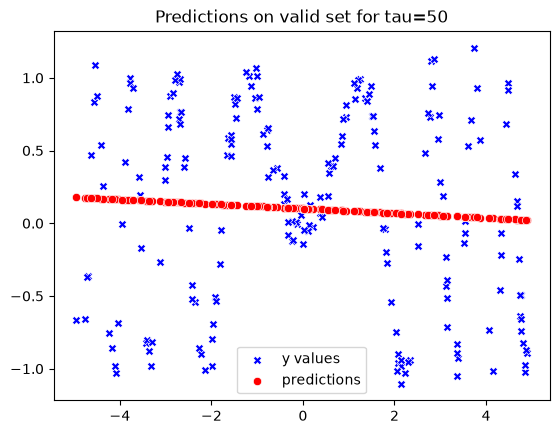

Best tau: 0.05


In [14]:
taus=[val for i in range(-2, 2, 1) for val in [1*10**i, 5*10**i]]
print(taus)
test_taus(taus)

[0.01, 0.03, 0.05, 0.07, 0.09, 0.11, 0.13, 0.15, 0.17, 0.19, 0.21]
tau=0.01, mse=0.22179058676378113


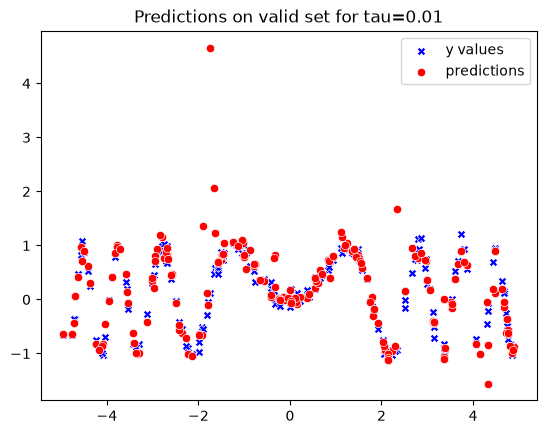

tau=0.03, mse=0.018096163123919786


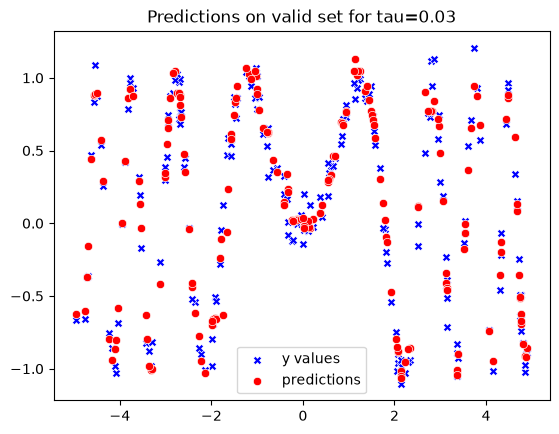

tau=0.05, mse=0.01240007615046591


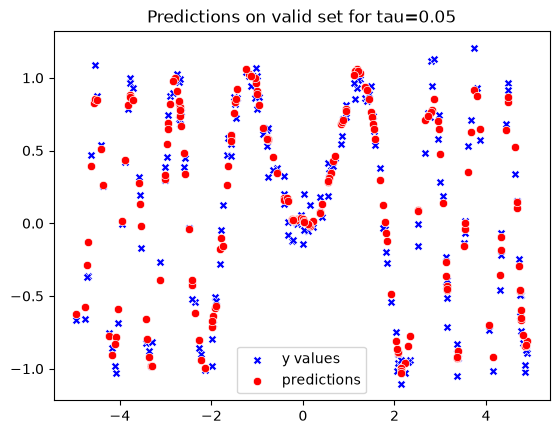

tau=0.07, mse=0.014318048402046535


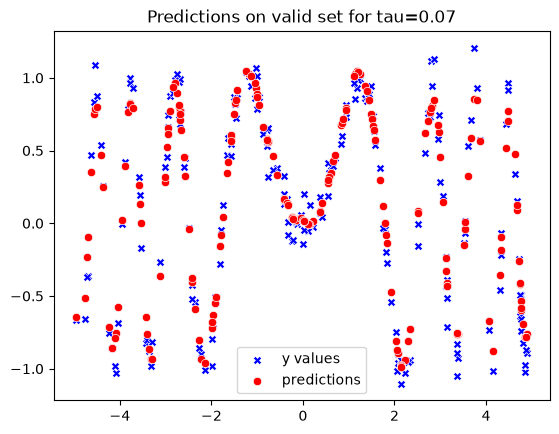

tau=0.09, mse=0.01999788210144499


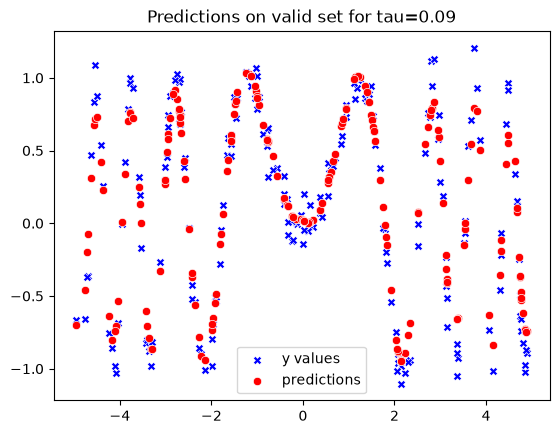

tau=0.11, mse=0.02948778778842267


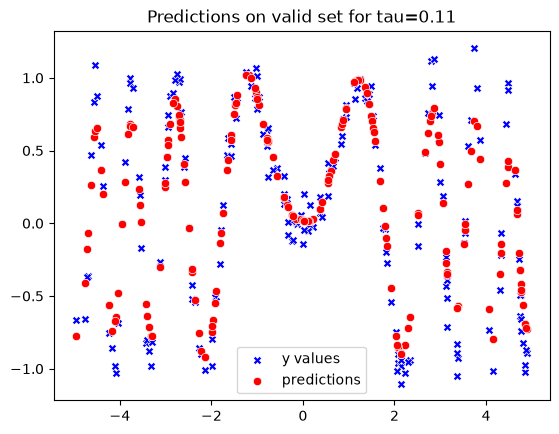

tau=0.13, mse=0.04324650595797072


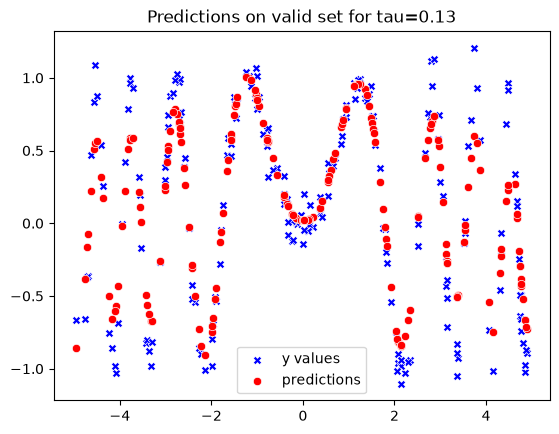

tau=0.15, mse=0.06093263371680287


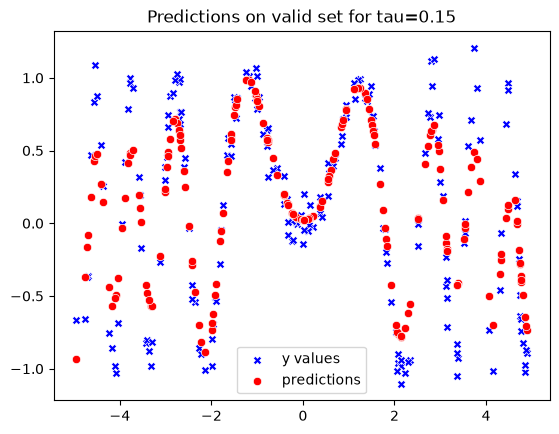

tau=0.17, mse=0.08146369201434983


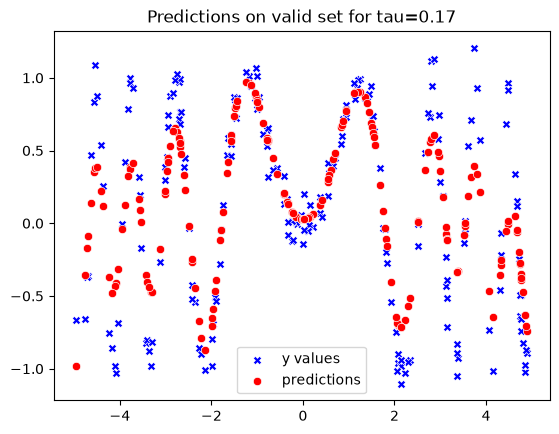

tau=0.19, mse=0.103540249450052


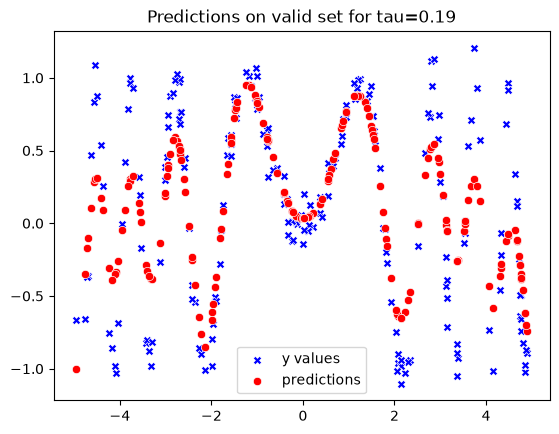

tau=0.21, mse=0.12604148808313087


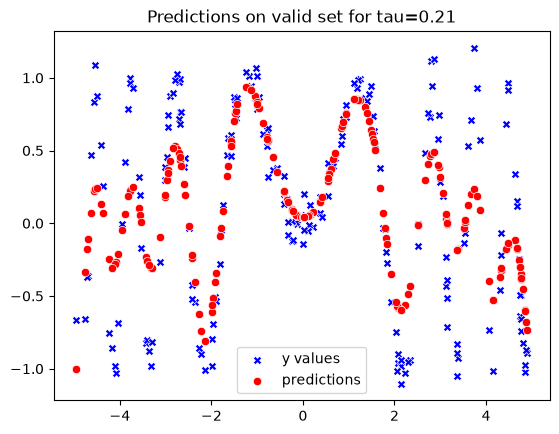

Best tau: 0.05


In [13]:
taus=[i/100 for i in range(1,22,2)]
print(taus)
test_taus(taus)